## Heat budget analysis

In [1]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json'

# esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-virtual-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ", plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/kr4383/access-cm3-paper-figs/


In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np
import cmocean as cm
import matplotlib as mpl

In [4]:
# client = Client(threads_per_worker=1)
# print(client.dashboard_link)

In [5]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [6]:
%%time

nyears = 20

# var_names = ['opottempdiff', 'opottemppmdiff', 
#              'rsdoabsorb', 'Th_tendency_vert_remap', 'opottemptend', 'T_advection_xy',
#             'boundary_forcing_heat_tendency', 'frazil_heat_tendency']

# var_names = ['boundary_forcing_heat_tendency',]

# heat_tendencies = dict()

# for var_name in var_names:
#     print('Loading', var_name)
#     darr = datastore.search(variable=var_name, frequency="1mon").to_dask(
#         xarray_open_kwargs = dict(
#             chunks={"yh": "auto", "xh": "auto", "time": 12},
#             decode_timedelta=True
#         )
#     )
#     heat_tendencies[var_name] = darr[var_name].isel(
#         time=slice(0, 12 * nyears)
#     ).mean(dim='time').compute()

#     heat_tendencies[var_name].to_netcdf(os.path.join(plotfolder, f"{var_name}_{nyears}_years.nc"))


CPU times: user 3 μs, sys: 5 μs, total: 8 μs
Wall time: 15.7 μs


In [7]:
%%time

nyears = 20

var_names = [
    'opottempdiff', 'opottemppmdiff', 'opottemptend', 
    'rsdoabsorb', 'Th_tendency_vert_remap', 'T_advection_xy', 'boundary_forcing_heat_tendency']
labels = [
    'Diabatic diffusion', 'Neutral diffusion', 'Non-lagrangian total', 
    'Penetrating shortwave', 'ALE remap', 'Horizontal advection', 'Coupler']

heat_tendencies = dict()

for var_name in var_names:
    print('Loading', var_name)
    fp = os.path.join(plotfolder, f"{var_name}_{nyears}_years.nc")
    heat_tendencies[var_name] = xr.load_dataset(fp)[var_name]

heat_tendencies = xr.Dataset(heat_tendencies)

Loading opottempdiff
Loading opottemppmdiff
Loading opottemptend
Loading rsdoabsorb
Loading Th_tendency_vert_remap
Loading T_advection_xy
Loading boundary_forcing_heat_tendency
CPU times: user 3.76 s, sys: 2.31 s, total: 6.06 s
Wall time: 7.71 s


In [8]:
# load in z* levels

tmp_df = xr.open_dataset(
    datastore.search(
        variable='opottemptend', frequency="1mon"
    ).df.path.values[0]
)
z_i = tmp_df.z_i.copy()
z_l = tmp_df.z_l.copy()

In [9]:
wet = datastore.search(variable="wet")
wet.df.drop_duplicates(subset='filename', inplace=True)
dstatic = xr.load_dataset(wet.df.path.values[0])
wet = wet.to_dask().compute()

areacello = datastore.search(variable="areacello")
areacello.df.drop_duplicates(subset='filename', inplace=True)
areacello = areacello.to_dask().compute()

areacello = (areacello.areacello * (wet.wet == 1.0))

## Load restarts + check whether $z^*$ levels are close enough

In [10]:
ic = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/19810101/atmos/MOM_IC.nc', decode_timedelta=False)
fc = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/20001201/atmos/access-cm3.mom6.r.2001-01-01-00000.nc', decode_timedelta=False)

In [11]:
ic1 = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/19810101/atmos/MOM_IC_1.nc', decode_timedelta=False)
fc1 = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/20001201/atmos/access-cm3.mom6.r.2001-01-01-00000_1.nc', decode_timedelta=False)

In [12]:
fc2 = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/20001201/atmos/access-cm3.mom6.r.2001-01-01-00000_2.nc', decode_timedelta=False)
fc3 = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/20001201/atmos/access-cm3.mom6.r.2001-01-01-00000_3.nc', decode_timedelta=False)

In [13]:
geo = xr.open_dataset('/scratch/tm70/kr4383/cylc-run/cm3-run-27-07-2026-PD-control/work/19810101/atmos/access-om3.mom6.geometry.nc', decode_timedelta=False)

In [14]:
depth = geo.D.compute()

In [15]:
h_ic = ic.h.isel(Time=0).load()
h_fc = fc.h.isel(Time=0).load()
wet_cell_mask = h_ic.data > (1e-3 + 1e-7)

In [16]:
# warning - MOM6 has 2 different estimates of surface height!
# sfc_initial = ic1.sfc.compute().isel(Time=0)
# sfc_final = fc1.sfc.compute().isel(Time=0)

sfc_initial = h_ic.sum('Layer') - depth
sfc_final = h_fc.sum('Layer') - depth

In [17]:
z_levels_initial = np.cumsum(h_ic.data[::-1], axis=0)[::-1] - depth.data[None]
z_levels_final = np.cumsum(h_fc.data[::-1], axis=0)[::-1] - depth.data[None]

In [18]:
zstar_levels_initial = (depth / (sfc_initial + depth)).data * (z_levels_initial - sfc_initial.data)
zstar_levels_final = (depth / (sfc_final + depth)).data * (z_levels_final - sfc_final.data)

In [19]:
zstar_diff = abs(zstar_levels_final - zstar_levels_initial)
zstar_diff[:-1][wet_cell_mask[1:]].max()

1.0197176436577138e-11

In [20]:
zstar_error = abs(-zstar_levels_initial - z_i.data[:-1, None, None])
print(zstar_error[:-1][wet_cell_mask[1:]].max())

5.456968210637558e-12


In [21]:
zstar_error = abs(-zstar_levels_final - z_i.data[:-1, None, None])
print(zstar_error[:-1][wet_cell_mask[1:]].max())

1.000435037691408e-11


## Calculate actual total temperature tendences on $z^*$ grid from restarts

On a diagonstic grid, MOM6 calculates quantities like:
$$R^{n+1}\Theta^{n+1}$$

and calculates the tendencies like:
$$R^{n+1} (\Theta^{n+1} - \Theta^n) $$

This means that the sum of tendencies does not give the change in the corresponding quantity
$$R^{n+1}\Theta^{n+1} - R^{n}\Theta^{n} \neq R^{n+1} (\Theta^{n+1} - \Theta^n) $$

The error term is
$$\Theta^{n} (R^{n+1} - R^n) $$

The is a purely advective term from the Lagrangian movement of the grid. We can calculate the actual total tendency on $z^*$ levels from the restarts, substract the MOM6 total tendency diagnostic, and consider the error term to be a vertical advection heat tendency.

At certain points the MOM6 total tendency diagnostic on $z^*$ (or other diagnostic) levels can give crazy values! Massive tendencies corresponding to 80C/yr heating can be observed, and this is averaged over 20 years.

In [22]:
cp = 3992.0
rho0 = 1035.0

heat_initial = (ic.h.isel(Time=0) * ic.Temp.isel(Time=0)) * cp * rho0
heat_final = (fc.h.isel(Time=0) * fc.Temp.isel(Time=0)) * cp * rho0

actual_heat_tendency = (heat_final - heat_initial) / (nyears * 365 * 24 * 3600)
actual_heat_tendency.data[~wet_cell_mask] = np.nan

In [23]:
heat_tendencies['Total'] = xr.DataArray(actual_heat_tendency.data, heat_tendencies['opottempdiff'].coords)
heat_tendencies['Vertical advection lagrangian'] = heat_tendencies['Total'] - heat_tendencies['opottemptend']
heat_tendencies['Vertical advection'] = heat_tendencies['Vertical advection lagrangian'] + heat_tendencies['Th_tendency_vert_remap']
heat_tendencies['Advection'] = heat_tendencies['Vertical advection'] + heat_tendencies['T_advection_xy']

In [24]:
var_names = list(heat_tendencies.data_vars.keys())

labels = [
    'Diabatic diffusion', 'Neutral diffusion', 'Non-lagrangian total', 
    'Penetrating shortwave', 'ALE remap', 'Horizontal advection', 'Coupler', 
    'Total', 'Vertical advection lagrangian', 'Vertical advection', 'Advection'
]

## Plot horizontally averaged fluxes

In [25]:
print(abs(heat_tendencies['opottempdiff'].sum(dim='z_l')).max().data)
print(abs(heat_tendencies['opottemppmdiff'].sum(dim='z_l')).max().data)

0.00048828125
959.8382568359375


In [26]:
avg_heat_tendencies = dict()

for var_name in var_names:
    avg_heat_tendencies[var_name] = heat_tendencies[var_name].weighted(areacello).sum(dim=('xh', 'yh'))
    avg_heat_tendencies[var_name] /= areacello.sum()

avg_heat_tendencies = xr.Dataset(avg_heat_tendencies)

In [27]:
print(abs(avg_heat_tendencies['opottempdiff'].sum(dim='z_l')).data)
print(abs(avg_heat_tendencies['opottemppmdiff'].sum(dim='z_l')).data)

7.582043159222625e-09
3.130992939416079e-11


In [28]:
exclude = [
    'Vertical advection', 'Horizontal advection', 'ALE remap', 
    'Vertical advection lagrangian', 'Non-lagrangian total', 'Penetrating shortwave']

print('Surface contributions')
for var_name, label in zip(var_names, labels):
    if not label in exclude:
        print(f'{label}: {avg_heat_tendencies[var_name].data[0]:.4f} W/m^2')

Surface contributions
Diabatic diffusion: 85.9667 W/m^2
Neutral diffusion: 0.0003 W/m^2
Coupler: -87.3226 W/m^2
Total: -0.0057 W/m^2
Advection: 1.2604 W/m^2


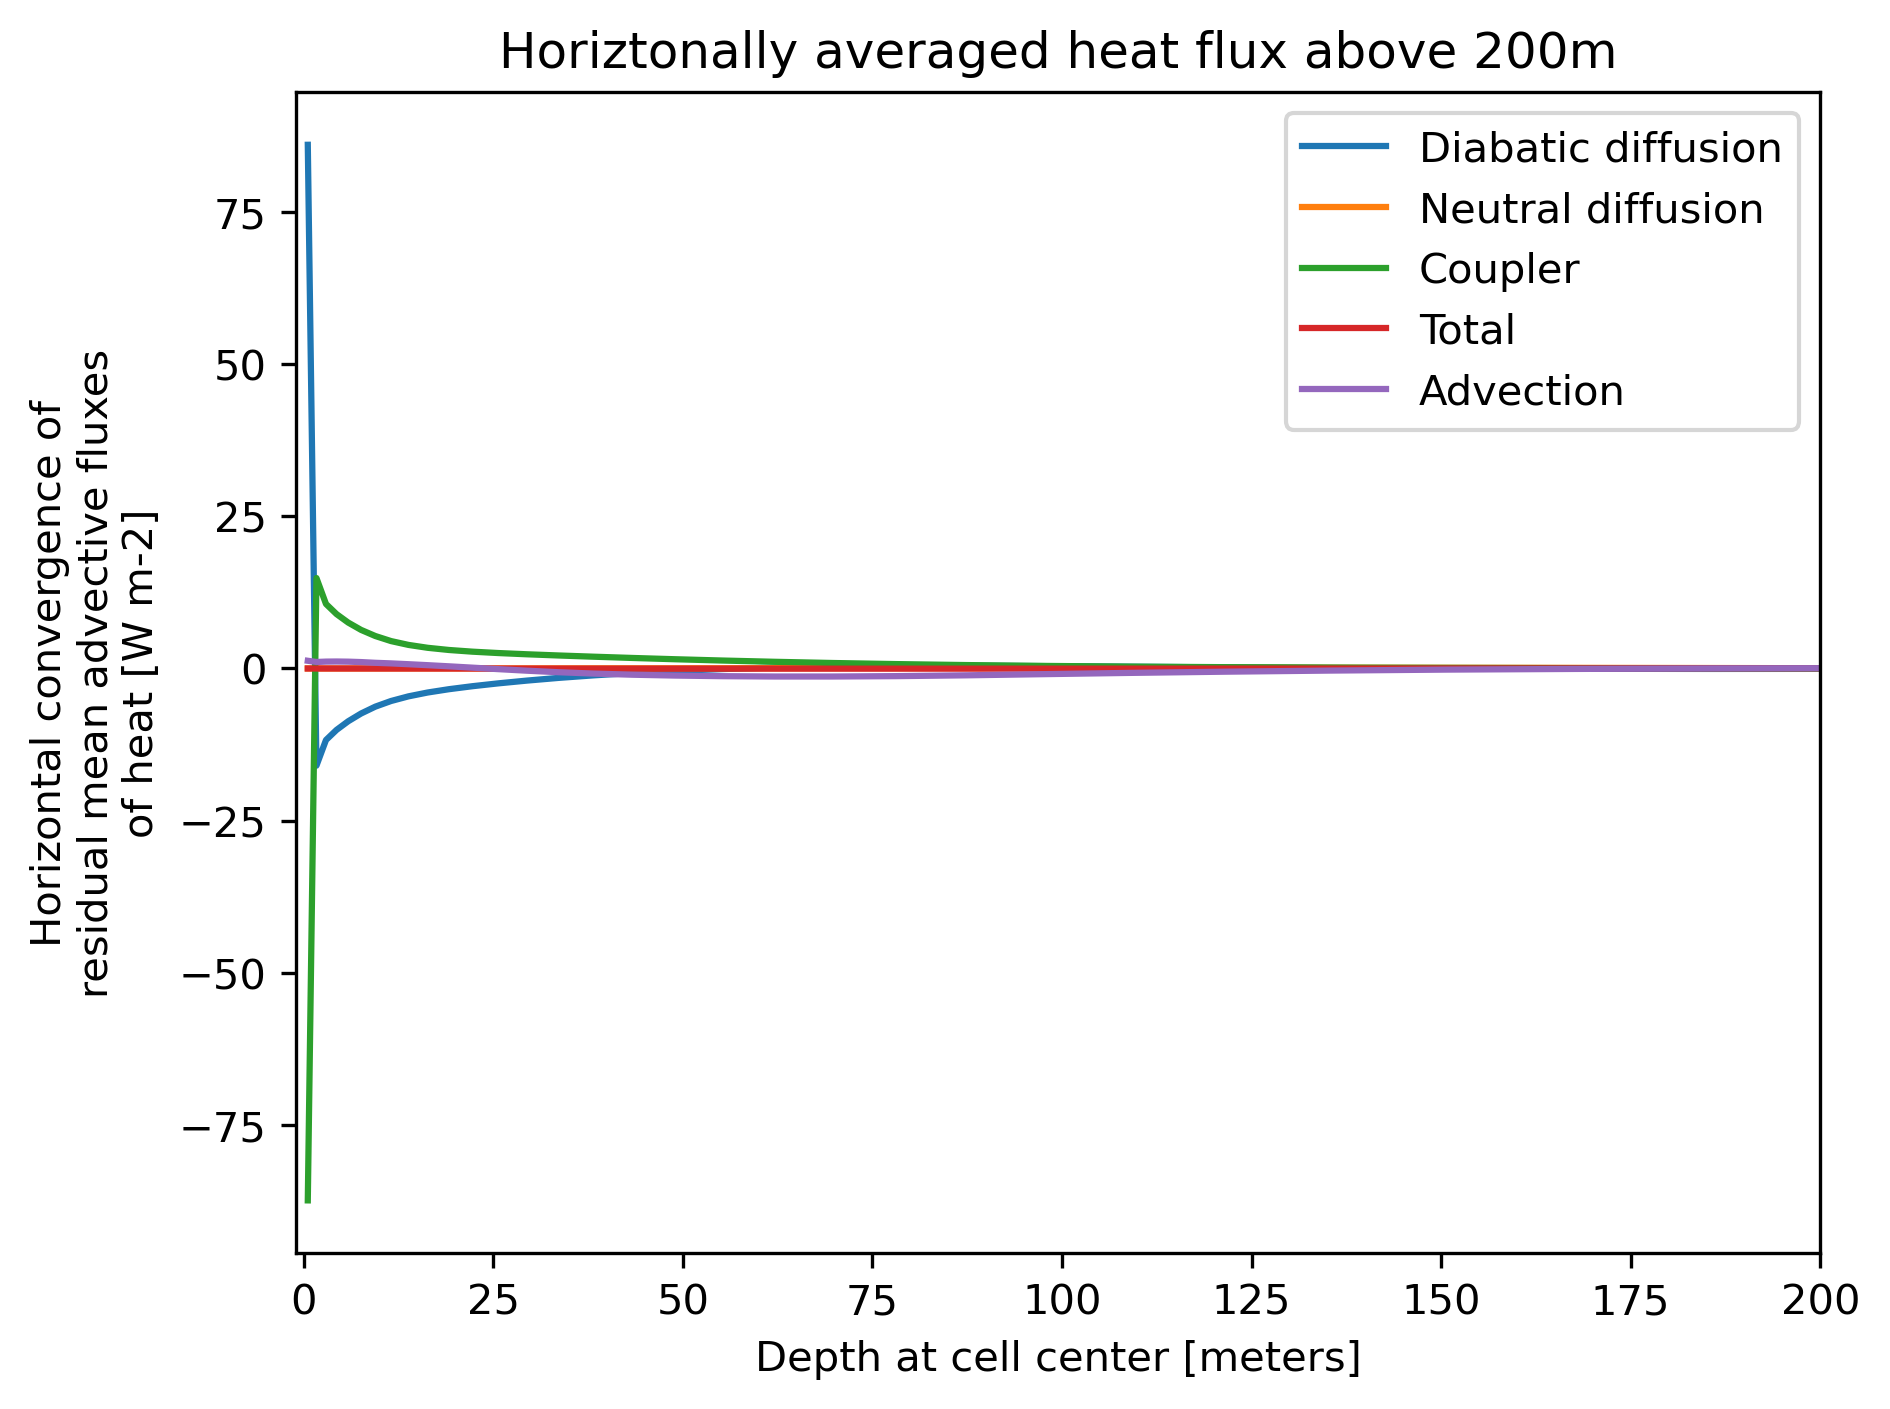

In [29]:
exclude = [
    'Vertical advection', 'Horizontal advection', 'ALE remap', 
    'Vertical advection lagrangian', 'Non-lagrangian total', 'Penetrating shortwave']

for var_name, label in zip(var_names, labels):
    if not label in exclude:
        avg_heat_tendencies[var_name].plot(label=label)

# avg_advection_heat_tendency = avg_heat_tendencies['Th_tendency_vert_remap'] + avg_heat_tendencies['T_advection_xy']
# avg_advection_heat_tendency.plot(label='Advection + remap')
plt.title('Horiztonally averaged heat flux above 200m')
plt.legend()
plt.xlim(-1, 200)
plt.tight_layout()

(-0.25, 0.25)

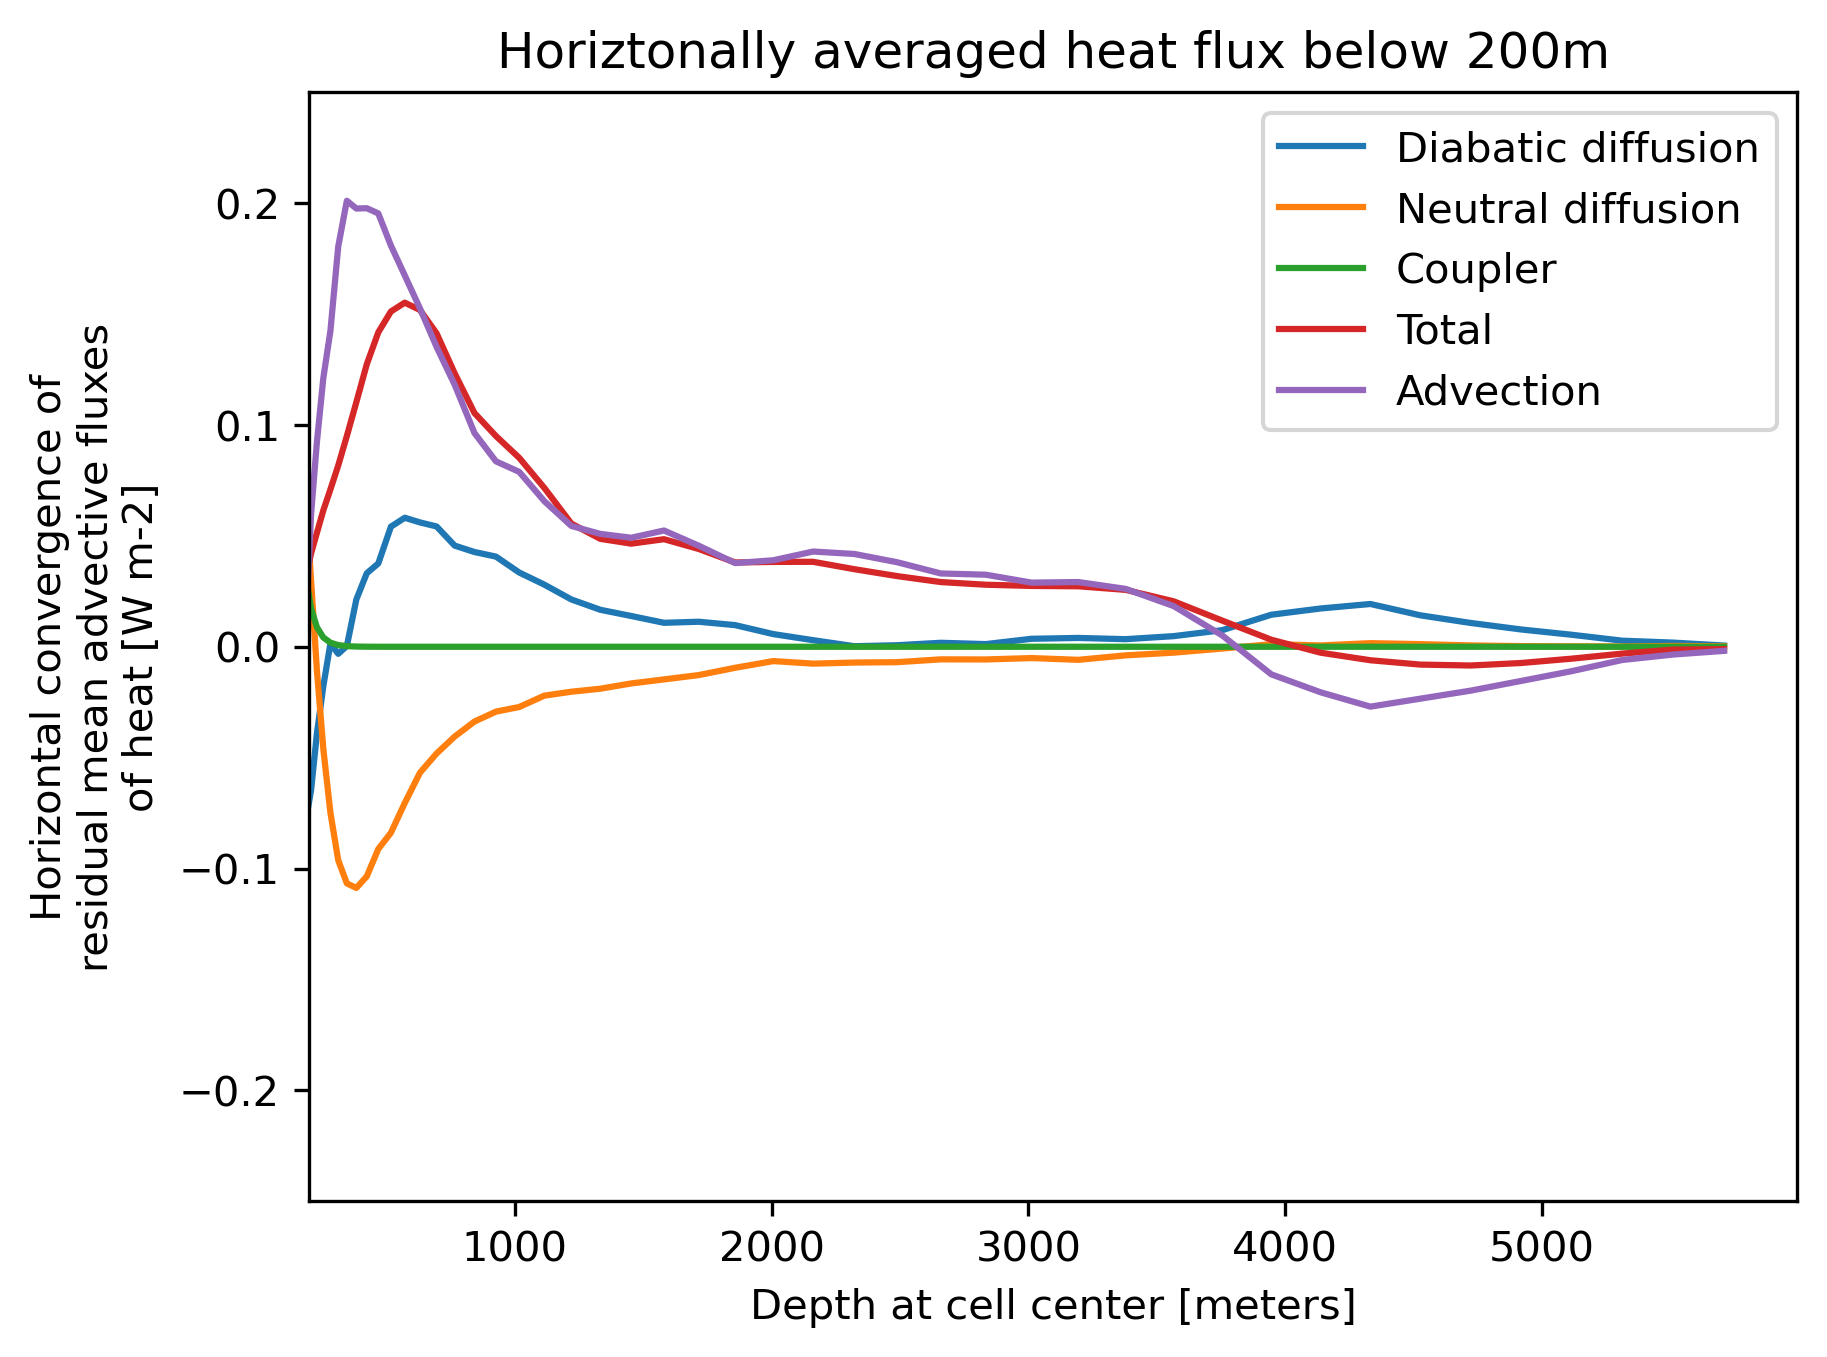

In [30]:

exclude = [
    'Vertical advection', 'Horizontal advection', 'ALE remap', 
    'Vertical advection lagrangian', 'Non-lagrangian total', 'Penetrating shortwave']
for var_name, label in zip(var_names, labels):
    if not label in exclude:
        avg_heat_tendencies[var_name].plot(label=label)

# avg_advection_heat_tendency = avg_heat_tendencies['Th_tendency_vert_remap'] + avg_heat_tendencies['T_advection_xy']
# avg_advection_heat_tendency.plot(label='Advection + remap')
# fig, ax = plt.subplots(figsize=(15,6))

plt.title('Horiztonally averaged heat flux below 200m')

plt.legend()
plt.xlim(200, None)
plt.ylim(-0.25, 0.25)

## Spatial distribution

### Advection heat below 200m

In [31]:
coords = datastore.search(variable=["geolat", "geolon"]).to_dask(
    preprocess=lambda ds: ds.set_coords(["geolat", "geolon"])
).reset_coords(["geolat", "geolon"]).compute()

coords = coords.fillna(0.0)

In [32]:
advection_heat_tendency = heat_tendencies['Advection']
advection_heat_tendency = advection_heat_tendency.assign_coords(coords)

In [33]:
idx_start = 30
idx_stop = -1
z_levels = advection_heat_tendency.z_l.data
print(f'Summing over depths {z_levels[idx_start]}m - {z_levels[idx_stop]}m')

Summing over depths 206.63652801513672m - 5709.44287109375m


In [34]:
deep_advection_heat_tendency = advection_heat_tendency.isel(z_l=slice(idx_start, None)).sum(dim='z_l')

In [35]:
print('Horizontally average heat flux:', (deep_advection_heat_tendency * areacello).sum().data / areacello.sum().data, 'W/m^2')

Horizontally average heat flux: 2.951225324204396 W/m^2


In [36]:
thresh = 5
mask = abs(deep_advection_heat_tendency) > thresh
print(f'Horizontally average heat flux (points > {thresh} W/m^2):', (deep_advection_heat_tendency * mask * areacello).sum().data / areacello.sum().data, 'W/m^2')

Horizontally average heat flux (points > 5 W/m^2): 3.0164319225770253 W/m^2


In [37]:
thresh = 50
mask = abs(deep_advection_heat_tendency) < thresh
print(f'Horizontally average heat flux (points < {thresh} W/m^2):', (deep_advection_heat_tendency * mask * areacello).sum().data / areacello.sum().data, 'W/m^2')

Horizontally average heat flux (points < 50 W/m^2): 2.139423549080155 W/m^2


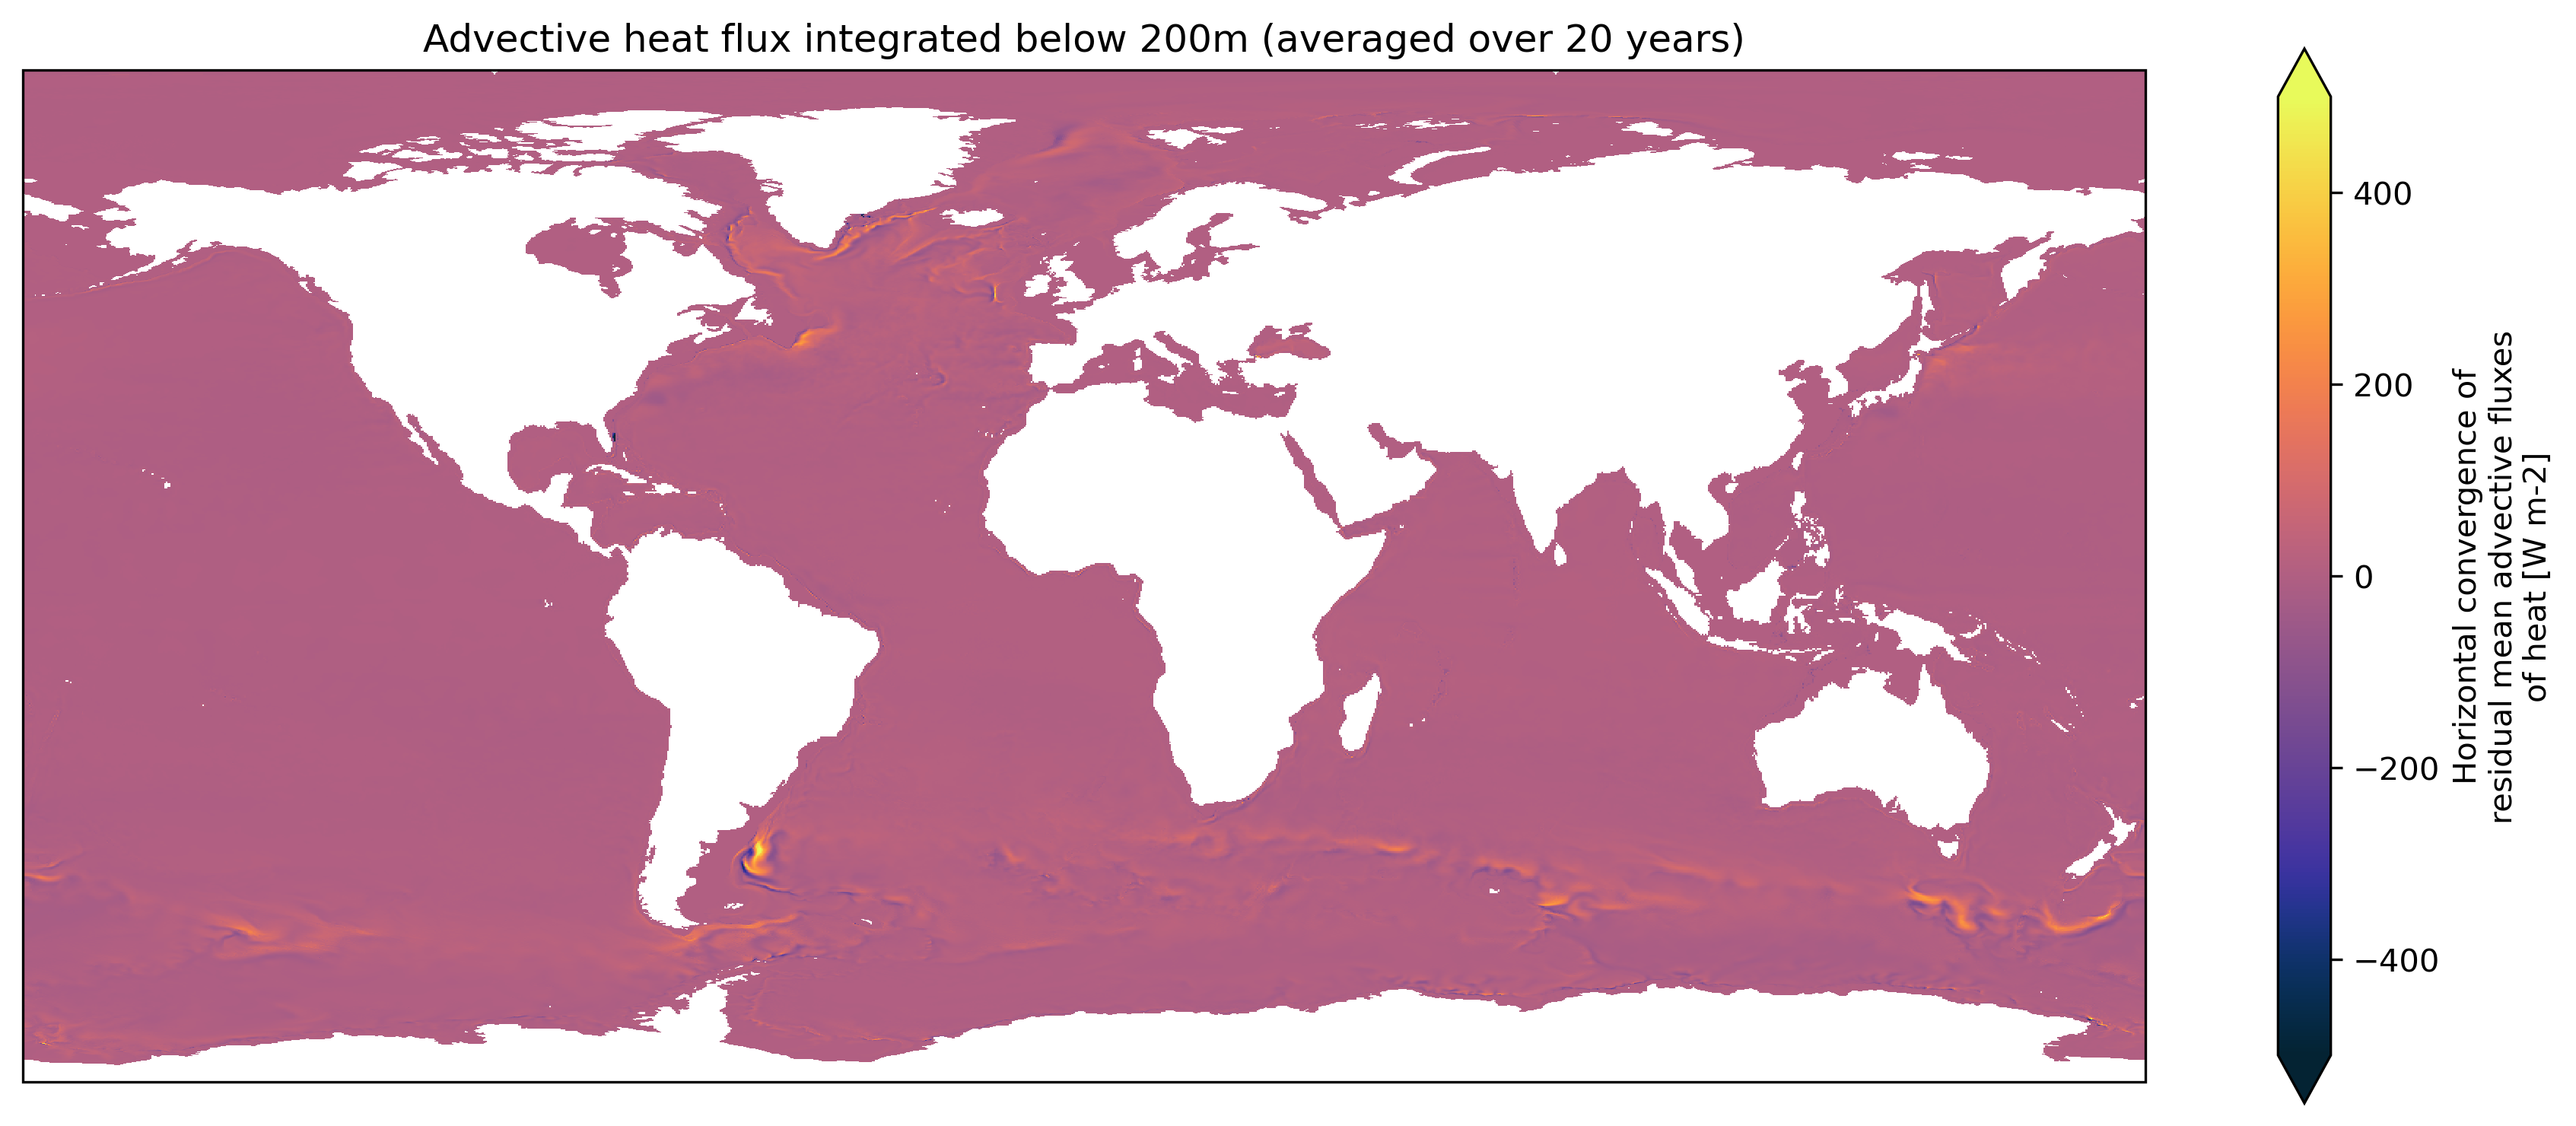

In [38]:
darr = deep_advection_heat_tendency.copy()
darr.data[wet.wet == 0] = np.nan
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

darr.plot(ax=ax, x="geolon", y="geolat", cmap=cm.cm.thermal, vmin=-500, vmax=500)
plt.title('Advective heat flux integrated below 200m (averaged over 20 years)')
plt.tick_params()

Text(0.5, 1.0, 'Advective heat tendency integrated below 200m (averaged over 20 years)')

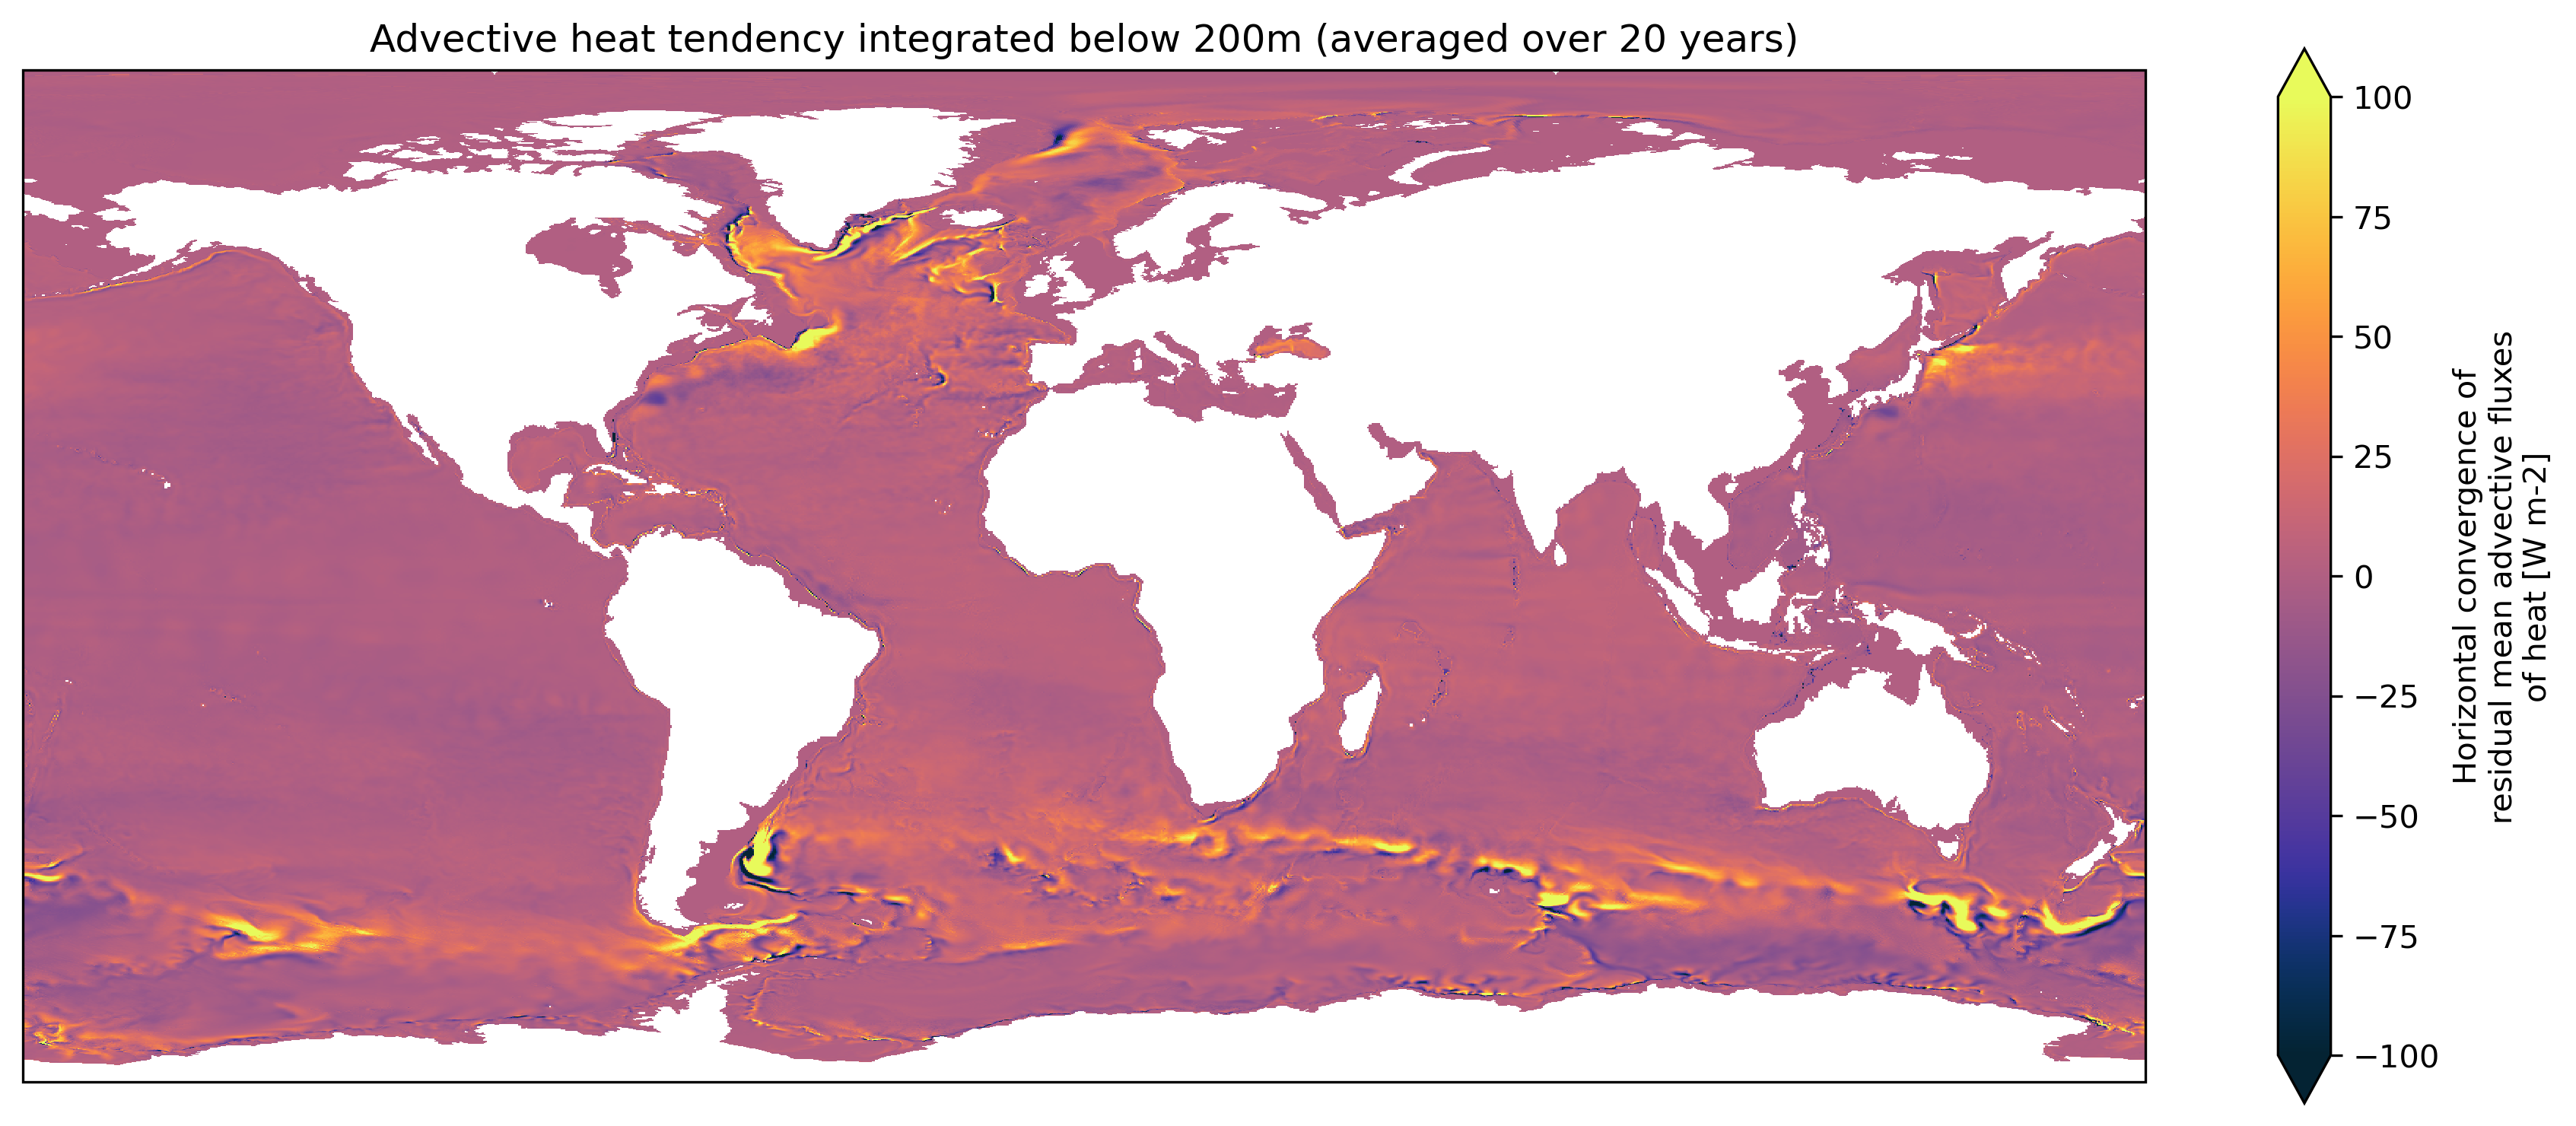

In [39]:
darr = deep_advection_heat_tendency.copy()
darr.data[wet.wet == 0] = np.nan
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

darr.plot(ax=ax, x="geolon", y="geolat", cmap=cm.cm.thermal, vmin=-100, vmax=100)
plt.title('Advective heat tendency integrated below 200m (averaged over 20 years)')


## Total heat tendency

In [40]:
total_heat_tendency = heat_tendencies['Total']
total_heat_tendency = advection_heat_tendency.assign_coords(coords)

In [41]:
deep_total_heat_tendency = total_heat_tendency.isel(z_l=slice(idx_start, None)).sum(dim='z_l')

In [42]:
print('Horizontally averaged heat flux:', (deep_total_heat_tendency * areacello).sum().data / areacello.sum().data, 'W/m^2')

Horizontally averaged heat flux: 2.951225324204396 W/m^2


Text(0.5, 1.0, 'Total heat tendency integrated below 200m (averaged over 20 years)')

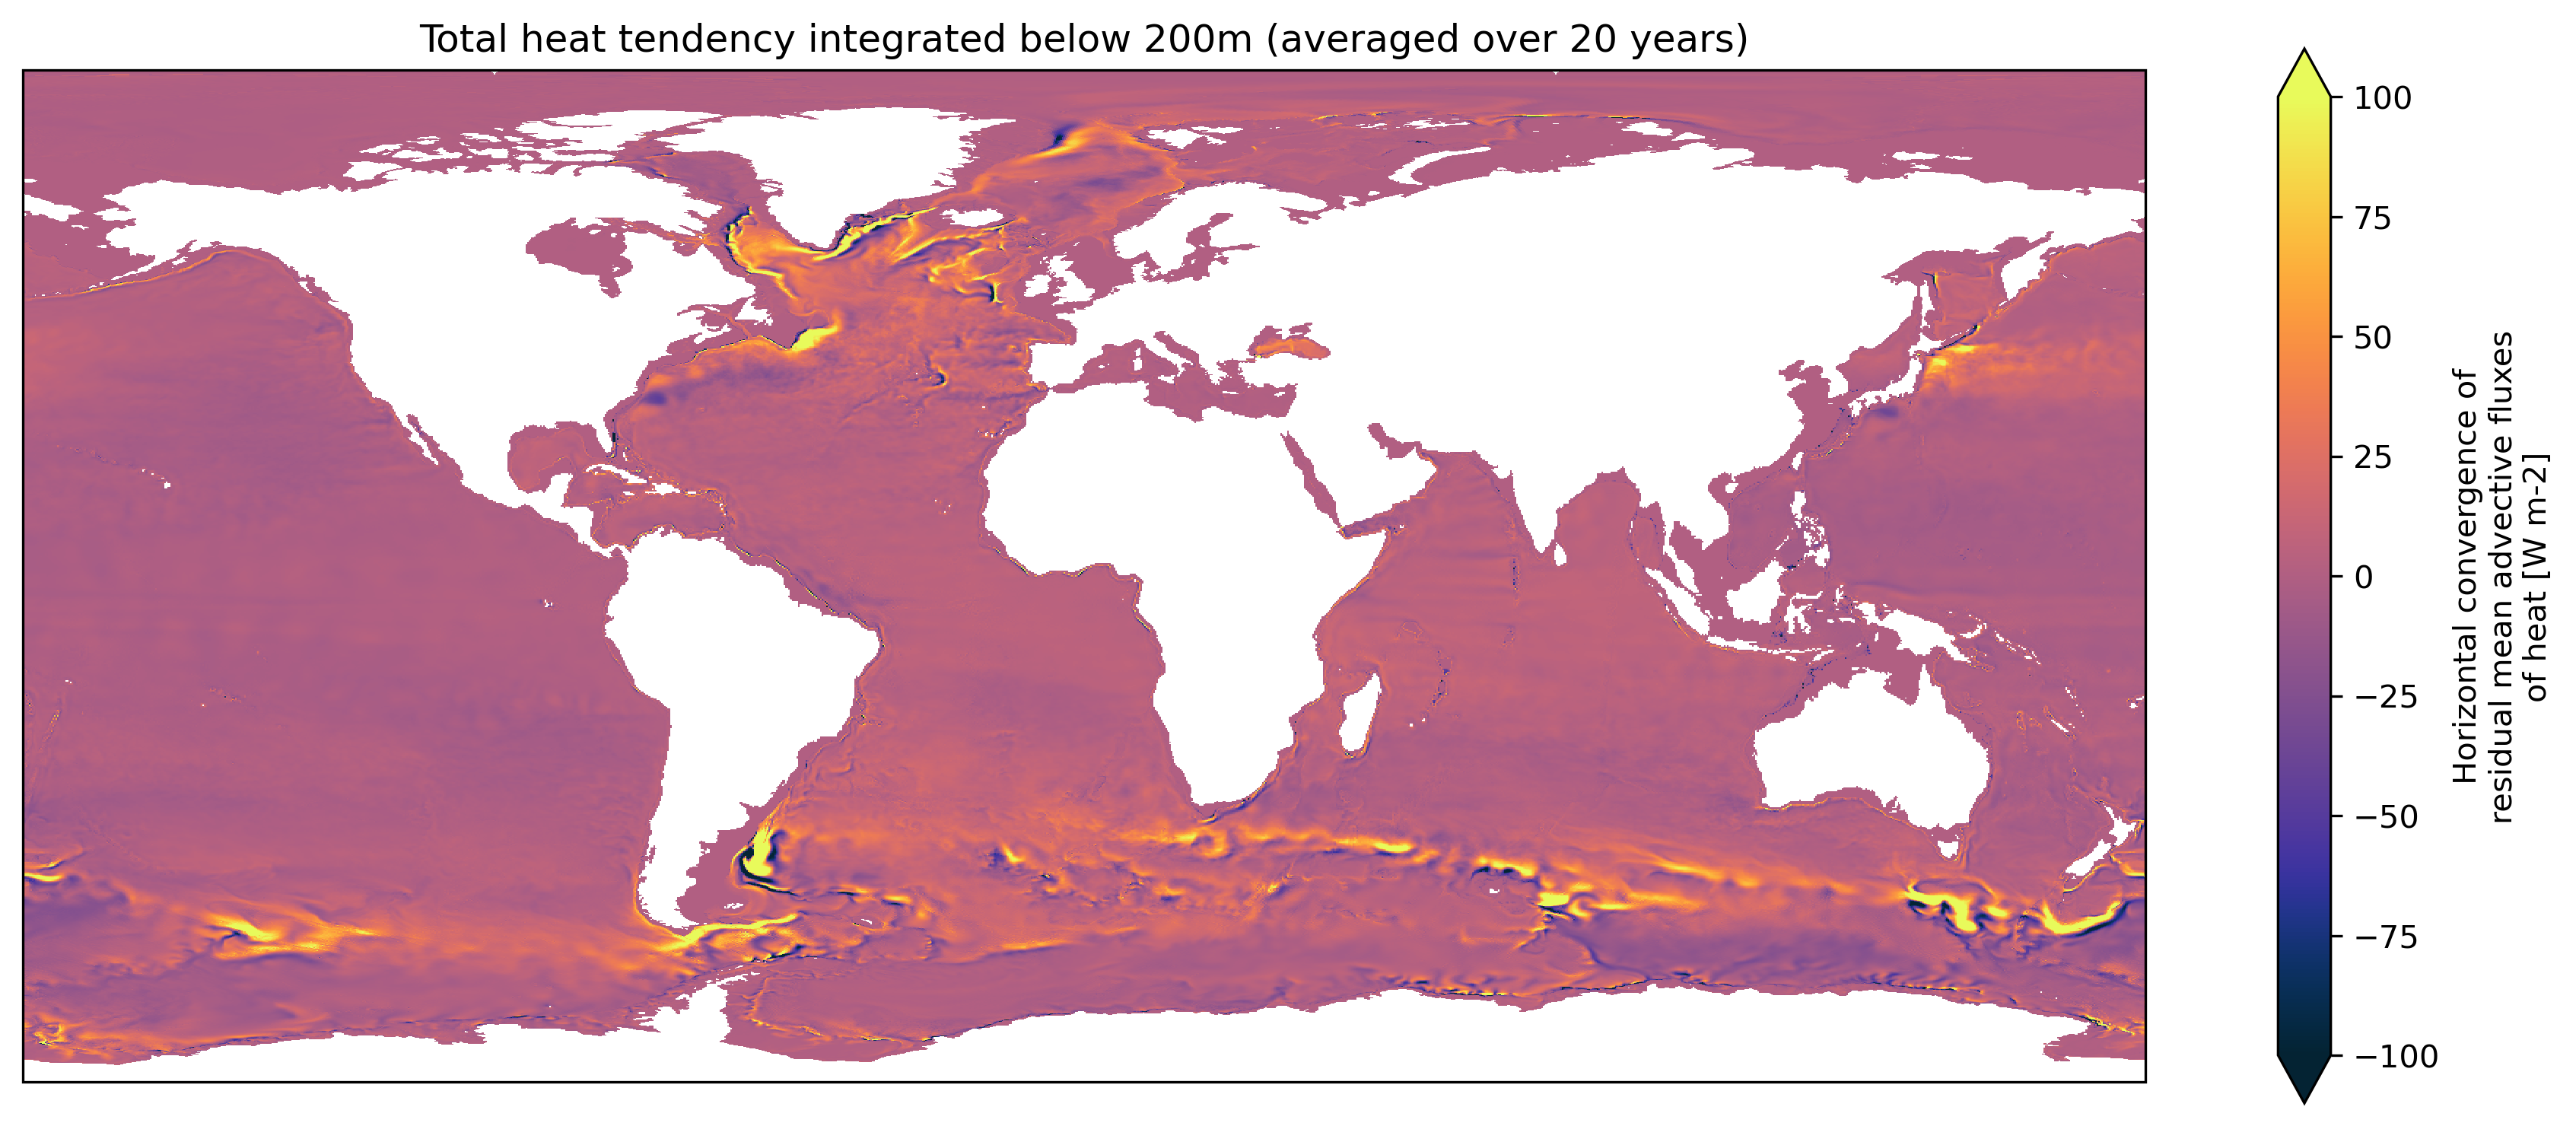

In [43]:
darr = deep_total_heat_tendency.copy()
darr.data[wet.wet == 0] = np.nan
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

darr.plot(ax=ax, x="geolon", y="geolat", cmap=cm.cm.thermal, vmin=-100, vmax=100)
plt.title('Total heat tendency integrated below 200m (averaged over 20 years)')


## Horizontal advection

In [44]:
horz_heat_tendency = heat_tendencies['T_advection_xy']
horz_heat_tendency = horz_heat_tendency.assign_coords(coords)

Text(0.5, 1.0, 'Horizontal advection heat tendency integrated full column (averaged over 20 years)')

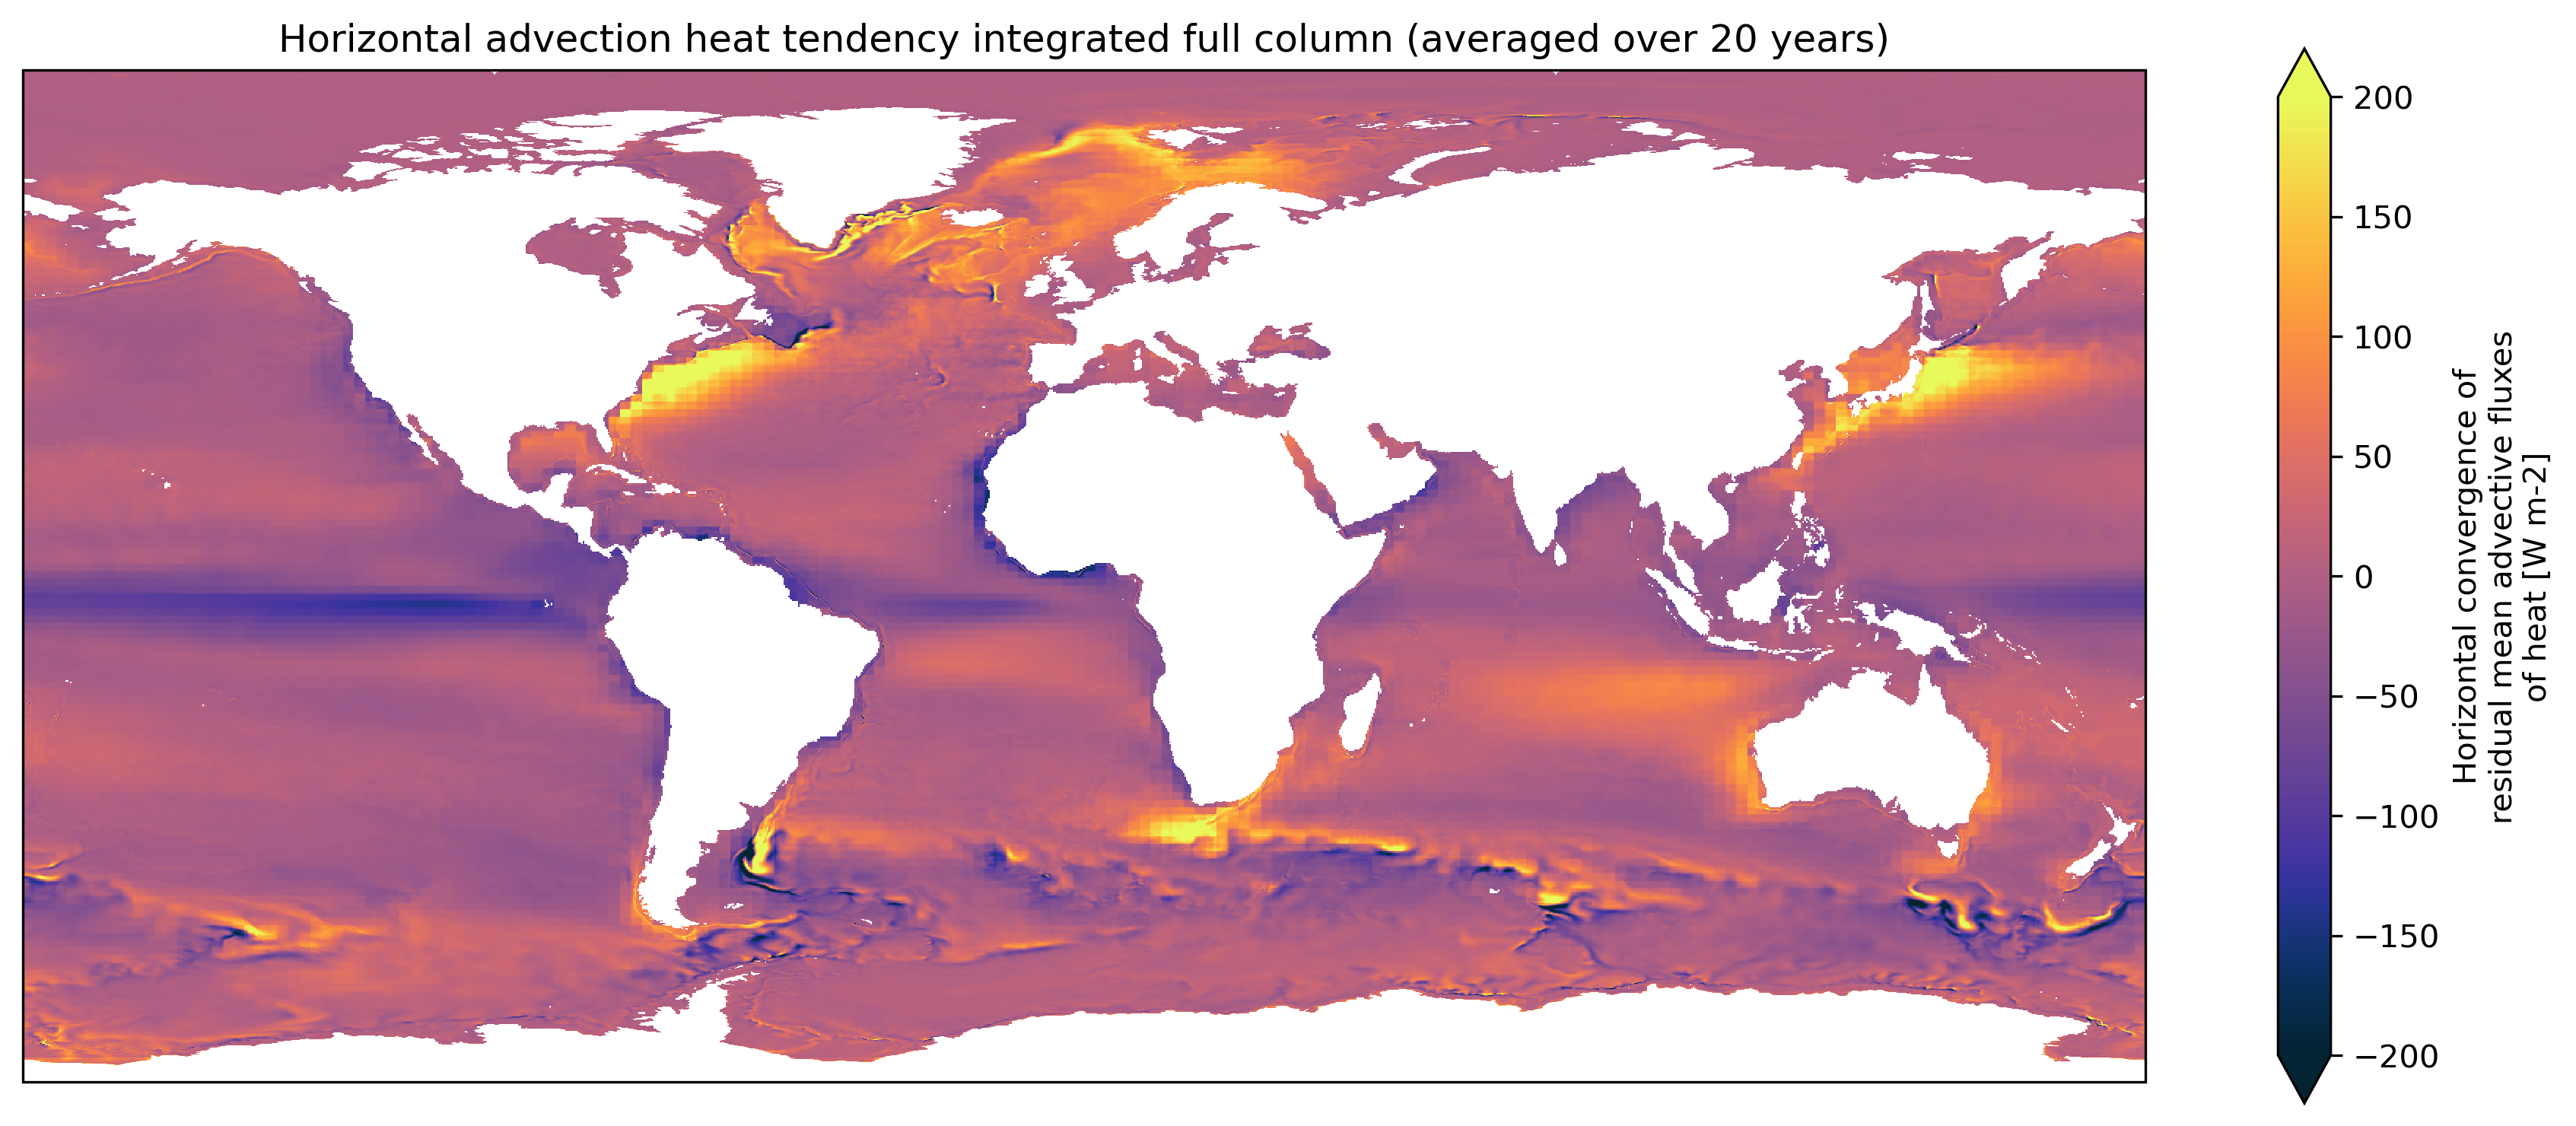

In [45]:
darr = horz_heat_tendency.sum(dim='z_l').copy()
darr.data[wet.wet == 0] = np.nan
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

darr.plot(ax=ax, x="geolon", y="geolat", cmap=cm.cm.thermal, vmin=-200, vmax=200)
plt.title('Horizontal advection heat tendency integrated full column (averaged over 20 years)')


##